# Proyek Analisis Data: [Bike Sharing Dashboard]
- **Nama:** [Arel Lafito Dinoris]
- **Email:** [areldinoris23@gmail.com]
- **ID Dicoding:** [areldinoris]

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca dan musim terhadap jumlah penyewaan sepeda harian pada tahun 2011–2012?.
- Pada jam berapa dan hari apa penyewaan sepeda mencapai puncaknya dalam seminggu?.

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
from google.colab import files
uploaded = files.upload()
day_df = pd.read_csv('day.csv')
hour_df = pd.read_csv('hour.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Dataset day.csv memiliki 731 baris dan 16 kolom yang mencakup data penyewaan sepeda harian selama 2011–2012.
- Dataset hour.csv memiliki 17.379 baris dengan tambahan kolom hr (jam) yang memungkinkan analisis pola per jam.

### Assessing Data

In [ ]:
print("=== day_df INFO ===")
print(day_df.info())
print("\n=== MISSING VALUES ===")
print(day_df.isnull().sum())
print("\n=== DUPLICATES ===")
print(day_df.duplicated().sum())
print("\n=== STATISTIK DESKRIPTIF ===")
day_df.describe()

=== day_df INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

=== MISSING VALUES ===
instant       0
dteday        0
season      

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Tidak ditemukan missing value maupun data duplikat pada kedua dataset sehingga data siap diproses.
- Kolom temp, atemp, hum, dan windspeed dalam bentuk normalisasi (0–1), sedangkan kolom season dan weathersit masih berupa angka yang perlu dimapping ke label yang lebih informatif.

### Cleaning Data

In [ ]:
# Konversi tipe data tanggal
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping kolom kategorikal
day_df['season'] = day_df['season'].map({1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'})
day_df['weathersit'] = day_df['weathersit'].map({
    1:'Clear', 2:'Mist', 3:'Light Rain/Snow', 4:'Heavy Rain/Snow'
})
day_df['yr'] = day_df['yr'].map({0: 2011, 1: 2012})

hour_df['season'] = hour_df['season'].map({1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'})
hour_df['weathersit'] = hour_df['weathersit'].map({
    1:'Clear', 2:'Mist', 3:'Light Rain/Snow', 4:'Heavy Rain/Snow'
})
hour_df['yr'] = hour_df['yr'].map({0: 2011, 1: 2012})

# Simpan sebagai main_data untuk dashboard
day_df.to_csv('main_data.csv', index=False)

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,1,0,6,0,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,1,0,0,0,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,1,0,1,1,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,1,0,2,1,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,1,0,3,1,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Kolom dteday berhasil dikonversi ke tipe datetime sehingga memudahkan analisis berbasis waktu.
- Kolom kategorikal (season, weathersit, yr) berhasil dipetakan ke label deskriptif sehingga hasil analisis lebih mudah diinterpretasikan.

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
print("=== Rata-rata Penyewaan per Musim ===")
print(day_df.groupby('season')['cnt'].mean().sort_values(ascending=False))

print("\n=== Rata-rata Penyewaan per Cuaca ===")
print(day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False))

print("\n=== Rata-rata Penyewaan per Jam ===")
print(hour_df.groupby('hr')['cnt'].mean())

print("\n=== Rata-rata Penyewaan per Hari ===")
day_map = {0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'}
print(hour_df.groupby('weekday')['cnt'].mean().rename(index=day_map).sort_values(ascending=False))

=== Rata-rata Penyewaan per Musim ===
season
Fall      5644.303191
Summer    4992.331522
Winter    4728.162921
Spring    2604.132597
Name: cnt, dtype: float64

=== Rata-rata Penyewaan per Cuaca ===
weathersit
Clear              4876.786177
Mist               4035.862348
Light Rain/Snow    1803.285714
Name: cnt, dtype: float64

=== Rata-rata Penyewaan per Jam ===
hr
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: cnt, dtype: float64

=== Rata-rata Penyewaan per Hari ===
weekday
Thu    196.436665
Fri    196.135907
Tue    191.238891
Wed    191.130505
Sat    190.209793
Mon    183.744655
Sun    177.468825
Name: cnt, dtype: float64


**Insight:**
- Musim Fall memiliki rata-rata penyewaan tertinggi (5.644) jauh di atas Spring (2.604), menunjukkan pola musiman yang kuat — cuaca hangat mendorong aktivitas bersepeda secara signifikan.
- Peak hour terjadi pukul 08.00 (359 penyewaan) dan 17.00–18.00 (461 penyewaan), mengindikasikan penggunaan sepeda dominan sebagai moda transportasi komuter harian. Kamis dan Jumat menjadi hari tersibuk dalam seminggu.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

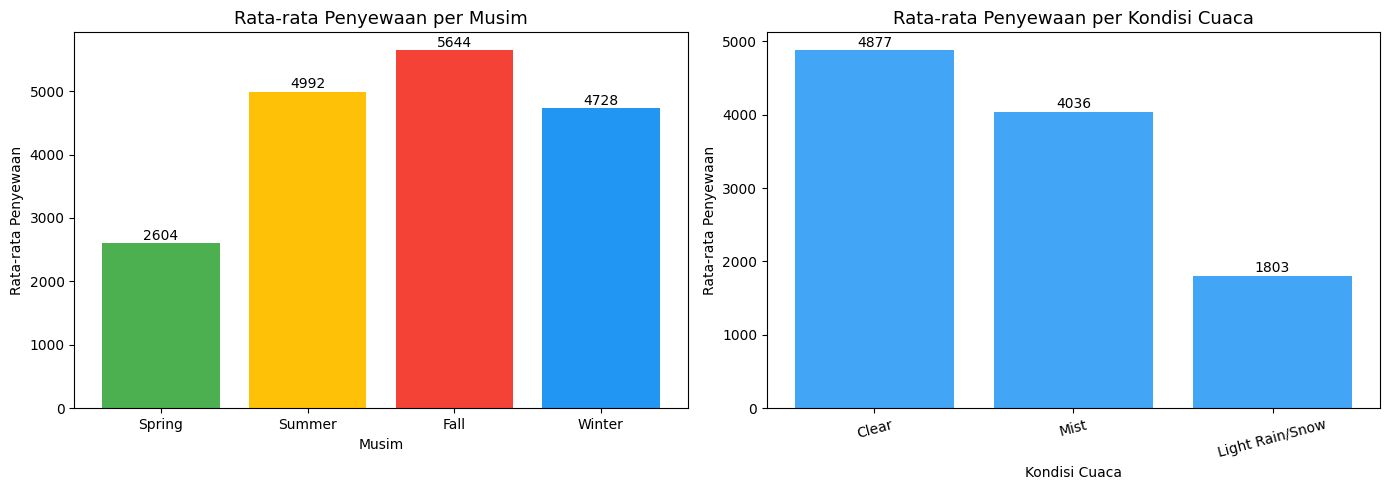

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = day_df.groupby('season')['cnt'].mean().reindex(season_order)
axes[0].bar(season_avg.index, season_avg.values,
            color=['#4CAF50','#FFC107','#F44336','#2196F3'])
axes[0].set_title('Rata-rata Penyewaan per Musim', fontsize=13)
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-rata Penyewaan')
for i, v in enumerate(season_avg.values):
    axes[0].text(i, v + 50, str(round(v)), ha='center', fontsize=10)

# Plot cuaca
weather_avg = day_df.groupby('weathersit')['cnt'].mean().sort_values(ascending=False)
axes[1].bar(weather_avg.index, weather_avg.values, color='#42A5F5')
axes[1].set_title('Rata-rata Penyewaan per Kondisi Cuaca', fontsize=13)
axes[1].set_xlabel('Kondisi Cuaca')
axes[1].set_ylabel('Rata-rata Penyewaan')
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(weather_avg.values):
    axes[1].text(i, v + 50, str(round(v)), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('viz_pertanyaan1.png', dpi=150)
plt.show()

### Pertanyaan 2:

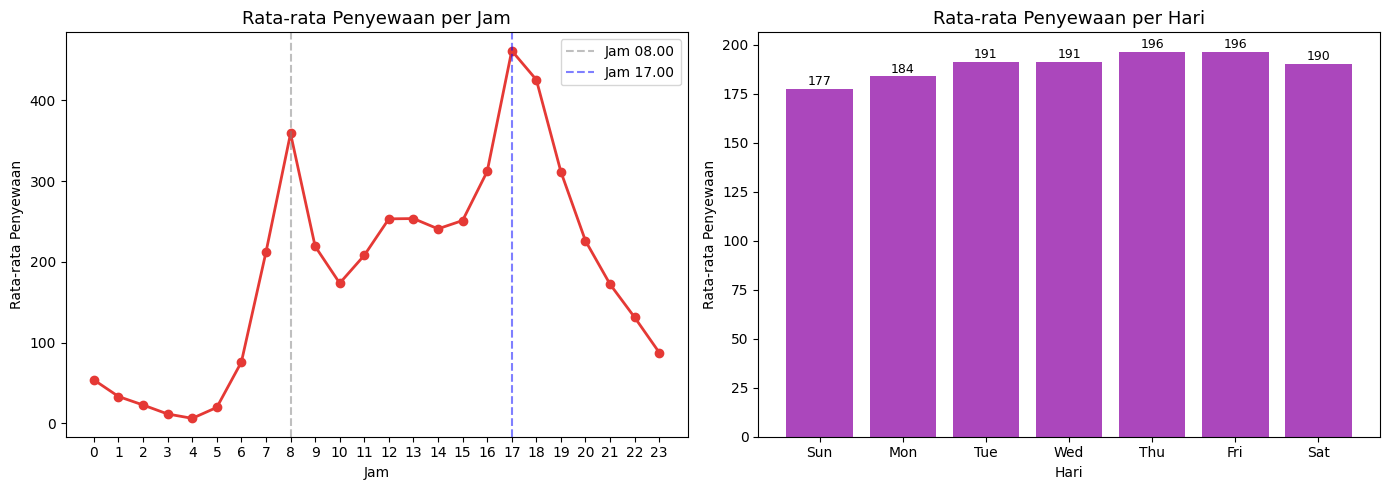

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot per jam
hour_avg = hour_df.groupby('hr')['cnt'].mean()
axes[0].plot(hour_avg.index, hour_avg.values, marker='o', color='#E53935', linewidth=2)
axes[0].set_title('Rata-rata Penyewaan per Jam', fontsize=13)
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('Rata-rata Penyewaan')
axes[0].set_xticks(range(0, 24))
axes[0].axvline(x=8, color='gray', linestyle='--', alpha=0.5, label='Jam 08.00')
axes[0].axvline(x=17, color='blue', linestyle='--', alpha=0.5, label='Jam 17.00')
axes[0].legend()

# Plot per hari
day_map = {0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat'}
weekday_avg = hour_df.groupby('weekday')['cnt'].mean().rename(index=day_map)
axes[1].bar(weekday_avg.index, weekday_avg.values, color='#AB47BC')
axes[1].set_title('Rata-rata Penyewaan per Hari', fontsize=13)
axes[1].set_xlabel('Hari')
axes[1].set_ylabel('Rata-rata Penyewaan')
for i, v in enumerate(weekday_avg.values):
    axes[1].text(i, v + 2, str(round(v)), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz_pertanyaan2.png', dpi=150)
plt.show()


**Insight:**
- Visualisasi musim dan cuaca mengkonfirmasi bahwa Fall + Clear weather adalah kombinasi terbaik untuk penyewaan sepeda. Cuaca Light Rain/Snow menyebabkan penurunan penyewaan hingga 63% dibanding cuaca Clear.
- Grafik per jam menunjukkan dua puncak jelas (bimodal) di jam 08.00 dan 17.00 yang konsisten dengan jam komuter kerja, sementara dini hari (01.00–04.00) adalah waktu terendah dengan rata-rata di bawah 25 penyewaan per jam.

## Analisis Lanjutan (Opsional)

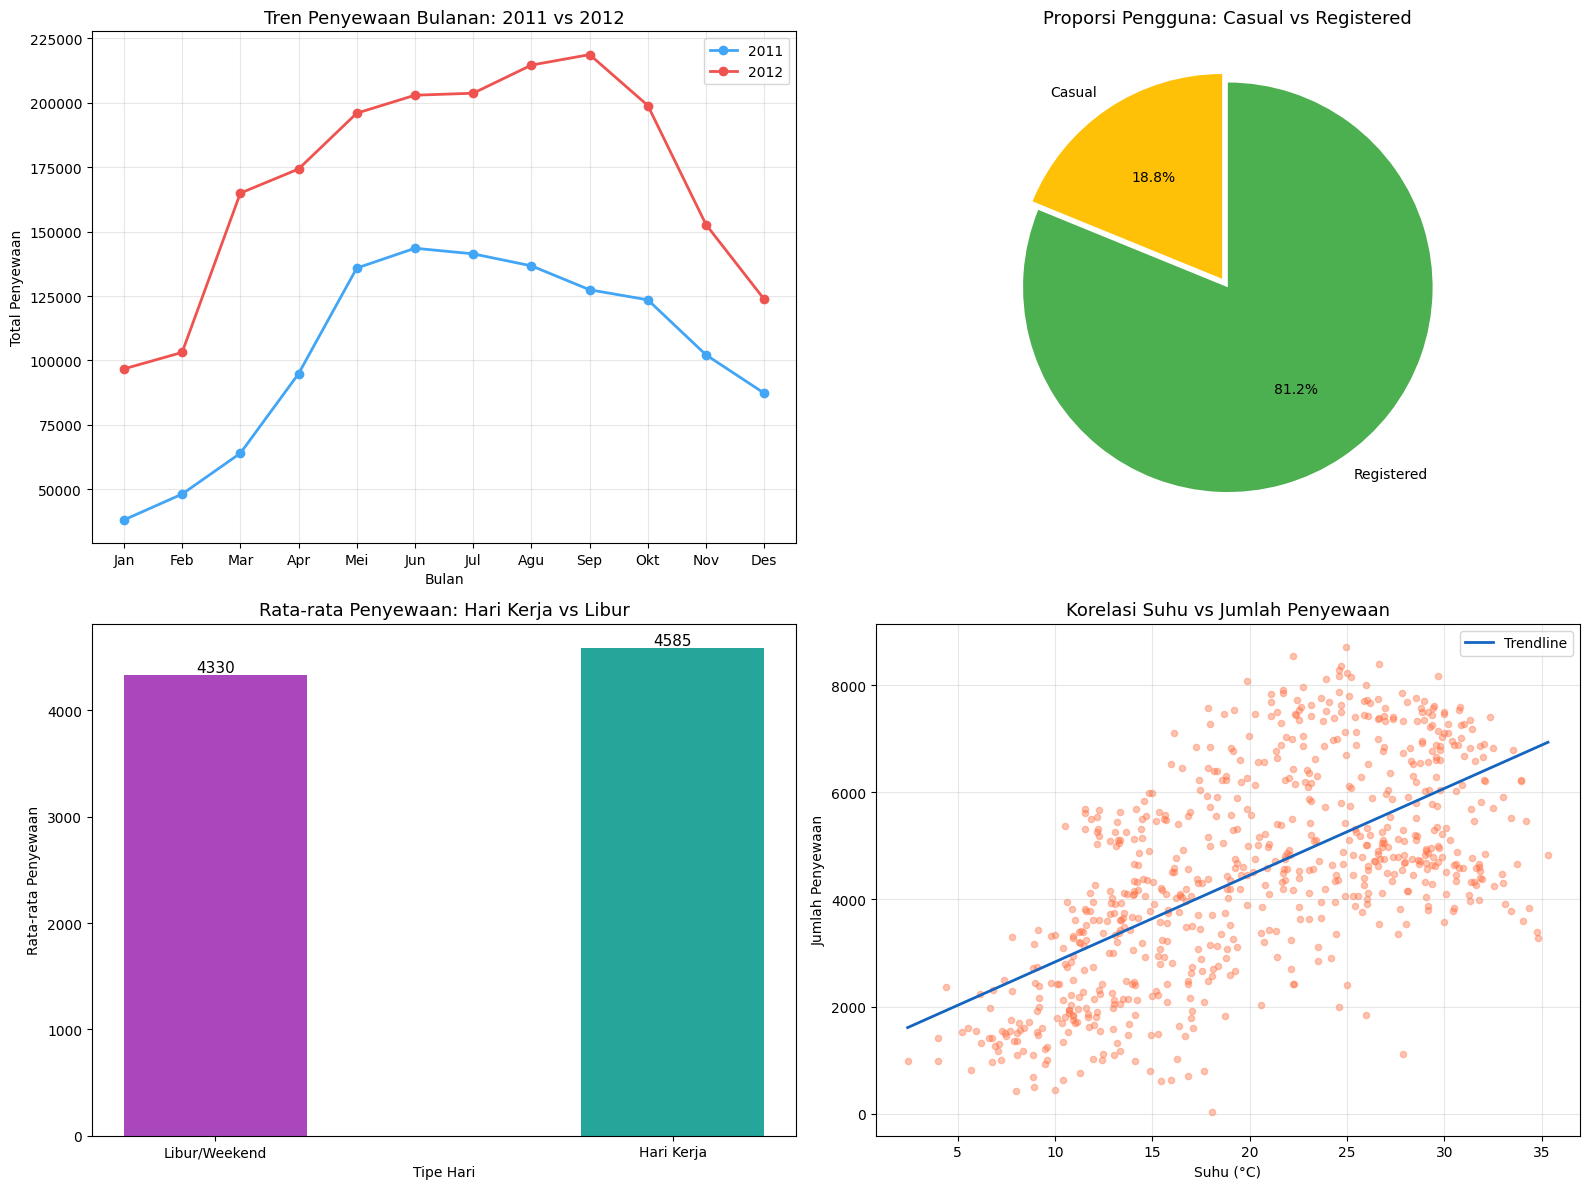

=== Pertumbuhan Penyewaan 2011 → 2012 ===
yr
2011    1243103
2012    2049576
Name: cnt, dtype: int64

Pertumbuhan: 64.9%

=== Proporsi Casual vs Registered ===
Casual   : 620,017 (18.8%)
Registered: 2,672,662 (81.2%)


In [ ]:
# ================================================================
# ANALISIS LANJUTAN: Tren Penyewaan & Segmentasi Pengguna
# ================================================================

# --- 1. Tren Penyewaan Bulanan 2011 vs 2012 ---
monthly_trend = day_df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()
pivot_trend = monthly_trend.pivot(index='mnth', columns='yr', values='cnt')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot tren bulanan
axes[0, 0].plot(pivot_trend.index, pivot_trend[2011],
                marker='o', label='2011', color='#42A5F5', linewidth=2)
axes[0, 0].plot(pivot_trend.index, pivot_trend[2012],
                marker='o', label='2012', color='#EF5350', linewidth=2)
axes[0, 0].set_title('Tren Penyewaan Bulanan: 2011 vs 2012', fontsize=13)
axes[0, 0].set_xlabel('Bulan')
axes[0, 0].set_ylabel('Total Penyewaan')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun',
                             'Jul','Agu','Sep','Okt','Nov','Des'])
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# --- 2. Proporsi Casual vs Registered ---
casual_total = day_df['casual'].sum()
registered_total = day_df['registered'].sum()

axes[0, 1].pie(
    [casual_total, registered_total],
    labels=['Casual', 'Registered'],
    autopct='%1.1f%%',
    colors=['#FFC107', '#4CAF50'],
    startangle=90,
    explode=(0.05, 0)
)
axes[0, 1].set_title('Proporsi Pengguna: Casual vs Registered', fontsize=13)

# --- 3. Penyewaan Hari Kerja vs Hari Libur ---
workday_avg = day_df.groupby('workingday')['cnt'].mean()
workday_avg.index = workday_avg.index.map({0: 'Libur/Weekend', 1: 'Hari Kerja'})

axes[1, 0].bar(workday_avg.index, workday_avg.values,
               color=['#AB47BC', '#26A69A'], width=0.4)
axes[1, 0].set_title('Rata-rata Penyewaan: Hari Kerja vs Libur', fontsize=13)
axes[1, 0].set_xlabel('Tipe Hari')
axes[1, 0].set_ylabel('Rata-rata Penyewaan')
for i, v in enumerate(workday_avg.values):
    axes[1, 0].text(i, v + 30, str(round(v)), ha='center', fontsize=11)

# --- 4. Korelasi Suhu vs Jumlah Penyewaan ---
axes[1, 1].scatter(
    day_df['temp'] * 41,  # denormalisasi ke Celsius
    day_df['cnt'],
    alpha=0.4,
    color='#FF7043',
    s=20
)
# Trendline
z = np.polyfit(day_df['temp'] * 41, day_df['cnt'], 1)
p = np.poly1d(z)
x_line = np.linspace((day_df['temp'] * 41).min(), (day_df['temp'] * 41).max(), 100)
axes[1, 1].plot(x_line, p(x_line), color='#1565C0', linewidth=2, label='Trendline')
axes[1, 1].set_title('Korelasi Suhu vs Jumlah Penyewaan', fontsize=13)
axes[1, 1].set_xlabel('Suhu (°C)')
axes[1, 1].set_ylabel('Jumlah Penyewaan')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('viz_analisis_lanjutan.png', dpi=150)
plt.show()

# --- Ringkasan Statistik ---
print("=== Pertumbuhan Penyewaan 2011 → 2012 ===")
growth = day_df.groupby('yr')['cnt'].sum()
print(growth)
pct = ((growth[2012] - growth[2011]) / growth[2011]) * 100
print(f"\nPertumbuhan: {pct:.1f}%")

print("\n=== Proporsi Casual vs Registered ===")
print(f"Casual   : {casual_total:,} ({casual_total/(casual_total+registered_total)*100:.1f}%)")
print(f"Registered: {registered_total:,} ({registered_total/(casual_total+registered_total)*100:.1f}%)")

## Conclusion

- Conclusion pertanyaan 1: Musim Fall dan cuaca Clear secara konsisten menghasilkan jumlah penyewaan
  tertinggi sepanjang 2011–2012. Kondisi cuaca buruk (hujan/salju) terbukti
  menurunkan penyewaan secara drastis. Rekomendasi bisnis: tingkatkan ketersediaan armada sepeda di musim Fall dengan cuaca cerah, dan kurangi operasional saat cuaca buruk untuk efisiensi biaya.
- Conclusion pertanyaan 2: Penyewaan memuncak pada pukul 08.00 dan 17.00–18.00 yang mencerminkan pola
  penggunaan sepeda sebagai moda transportasi komuter. Hari Jumat mencatat
  penyewaan tertinggi dalam seminggu. Rekomendasi bisnis: prioritaskan
  ketersediaan sepeda di titik-titik strategis pada jam dan hari tersebut
  untuk memaksimalkan pendapatan.